In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dense, Dropout

In [2]:
df = pd.read_csv("../data/processed/SBIN.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print("Shape:", df.shape)
print("\nStart Date:", df["Date"].min())
print("End Date:", df["Date"].max())

df.head()

Shape: (2878, 8)

Start Date: 2015-01-01 00:00:00
End Date: 2026-08-24 00:00:00


,Date,Adj Close,Close,High,Low,Open,Volume,Stock
0,2015-01-01,274.924988,314.000000,315.000000,310.700012,312.450012,6138488,SBIN
1,2015-01-02,276.019440,315.250000,318.299988,314.350006,314.350006,9935094,SBIN
2,2015-01-05,273.830566,312.750000,316.799988,312.100006,316.250000,9136716,SBIN
3,2015-01-06,262.579651,299.899994,311.100006,298.700012,310.000000,15329257,SBIN
4,2015-01-07,262.798492,300.149994,302.549988,295.149994,300.000000,15046745,SBIN


In [3]:
# Select only the Close price
data = df[["Close"]].values

# 80% training data
training_size = int(len(data) * 0.8)

# Split chronologically (DO NOT shuffle time-series data)
train_data = data[:training_size]
test_data = data[training_size:]

print("Total records:", len(data))
print("Training records:", len(train_data))
print("Testing records:", len(test_data))

print("\nTrain period:")
print(df["Date"].iloc[0], "to", df["Date"].iloc[training_size - 1])

print("\nTest period:")
print(df["Date"].iloc[training_size], "to", df["Date"].iloc[-1])

Total records: 2878
Training records: 2302
Testing records: 576

Train period:
2015-01-01 00:00:00 to 2024-05-02 00:00:00

Test period:
2024-05-03 00:00:00 to 2026-08-24 00:00:00


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit scaler ONLY on training data
train_scaled = scaler.fit_transform(train_data)

# Transform test data using the SAME scaler
test_scaled = scaler.transform(test_data)

print("Train scaled shape:", train_scaled.shape)
print("Test scaled shape:", test_scaled.shape)

print("\nFirst 5 scaled training values:")
print(train_scaled[:5])

print("\nFirst 5 scaled testing values:")
print(test_scaled[:5])

Train scaled shape: (2302, 1)
Test scaled shape: (576, 1)

First 5 scaled training values:
[[0.24020907]
 [0.24204947]
 [0.23836867]
 [0.21944934]
 [0.21981742]]

First 5 scaled testing values:
[[1.00206128]
 [0.96724087]
 [0.95855423]
 [0.97165783]
 [0.98490872]]


In [5]:
sequence_length = 60

X_train = []
y_train = []

for i in range(sequence_length, len(train_scaled)):
    X_train.append(train_scaled[i-sequence_length:i, 0])
    y_train.append(train_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nFirst sequence:")
print(X_train[0][:10])

print("\nTarget:")
print(y_train[0])

X_train shape: (2242, 60)
y_train shape: (2242,)

First sequence:
[0.24020907 0.24204947 0.23836867 0.21944934 0.21981742 0.22673734
 0.22430802 0.23005007 0.22710542 0.22651651]

Target:
0.17108360545065887


In [6]:
test_input = np.concatenate(
    (train_scaled[-sequence_length:], test_scaled),
    axis=0
)

X_test = []
y_test = []

for i in range(sequence_length, len(test_input)):
    X_test.append(test_input[i-sequence_length:i, 0])
    y_test.append(test_input[i, 0])

X_test = np.array(X_test)
y_test = np.array(y_test)

print("Test input shape:", test_input.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nExpected test predictions:", len(X_test))

Test input shape: (636, 1)
X_test shape: (576, 60)
y_test shape: (576,)

Expected test predictions: 576


In [7]:
X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2242, 60, 1)
y_train shape: (2242,)

X_test shape: (576, 60, 1)
y_test shape: (576,)


In [8]:
model = Sequential([
    Input(shape=(X_train.shape[1], 1)),

    Bidirectional(
        LSTM(50, return_sequences=False)
    ),

    Dropout(0.2),

    Dense(25, activation="relu"),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 100)                 │          20,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           2,525 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,351 (91.21 KB)

 Trainable params: 23,351 (91.21 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0115 - val_loss: 0.0043
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0017 - val_loss: 0.0022
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0014 - val_loss: 0.0021
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0011 - val_loss: 0.0047
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0010 - val_loss: 0.0016
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 9.2509e-04 - val_loss: 0.0018
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 8.1846e-04 - val_loss: 0.0017
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7.3503e-04 - val_loss: 0.0014
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 6.2960e-04 - val_loss: 0.0017
Epoch 10/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 7.1350e-04 - val_loss: 0.0043
Epoch 11/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.7452e-04 - val_loss: 0.0020
Epoch 12/100
71/71 ━━━━━━━━━

In [10]:
# Predict on test data
predictions_scaled = model.predict(X_test)

# Convert predictions back to original stock price scale
predictions = scaler.inverse_transform(predictions_scaled)

# Convert actual test values back to original scale
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Predictions shape:", predictions.shape)
print("Actual prices shape:", actual_prices.shape)

print("\nFirst 5 predictions:")

for i in range(5):
    print(
        f"Actual: ₹{actual_prices[i][0]:.2f} | "
        f"Predicted: ₹{predictions[i][0]:.2f}"
    )

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Predictions shape: (576, 1)
Actual prices shape: (576, 1)

First 5 predictions:
Actual: ₹831.45 | Predicted: ₹833.41
Actual: ₹807.80 | Predicted: ₹835.96
Actual: ₹801.90 | Predicted: ₹819.41
Actual: ₹810.80 | Predicted: ₹810.44
Actual: ₹819.80 | Predicted: ₹816.11


In [11]:
# Calculate evaluation metrics

mae = mean_absolute_error(actual_prices, predictions)

rmse = np.sqrt(
    mean_squared_error(actual_prices, predictions)
)

mape = np.mean(
    np.abs(
        (actual_prices - predictions) / actual_prices
    )
) * 100

r2 = r2_score(actual_prices, predictions)

print("===== BiLSTM FORECAST RESULTS =====")
print(f"MAE: ₹{mae:.2f}")
print(f"RMSE: ₹{rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R² Score: {r2:.4f}")

===== BiLSTM FORECAST RESULTS =====
MAE: ₹36.24
RMSE: ₹48.57
MAPE: 3.79%
R² Score: 0.8363


In [13]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "LSTM",
        "GRU",
        "CNN-LSTM",
        "BiLSTM"
    ],

    "MAE (₹)": [
        12.03,
        11.81,
        33.25,
        36.24
    ],

    "RMSE (₹)": [
        16.44,
        16.14,
        36.07,
        48.57
    ],

    "MAPE (%)": [
        1.35,
        1.32,
        3.75,
        3.79
    ],

    "R² Score": [
        0.9812,
        0.9819,
        0.9097,
        0.8363
    ]
})

model_comparison

,Model,MAE (₹),RMSE (₹),MAPE (%),R² Score
0,LSTM,12.03,16.44,1.35,0.9812
1,GRU,11.81,16.14,1.32,0.9819
2,CNN-LSTM,33.25,36.07,3.75,0.9097
3,BiLSTM,36.24,48.57,3.79,0.8363


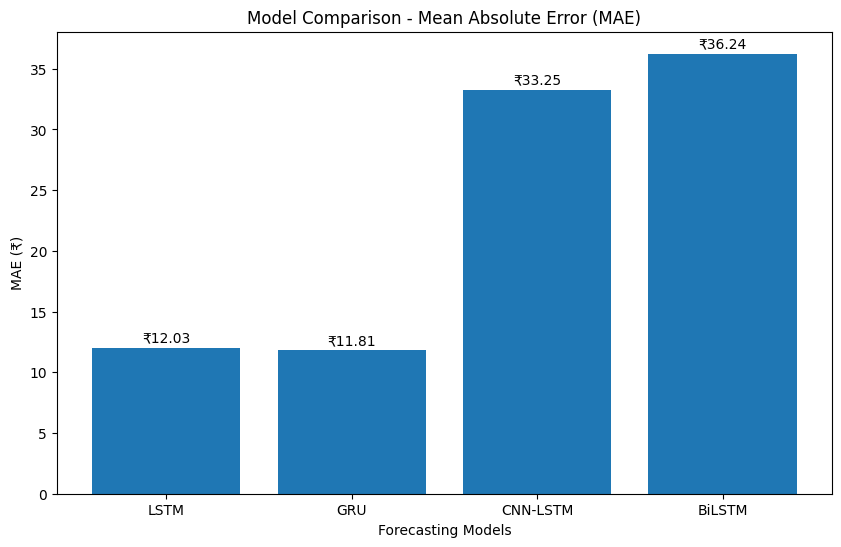

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_comparison["Model"],
    model_comparison["MAE (₹)"]
)

plt.title("Model Comparison - Mean Absolute Error (MAE)")
plt.xlabel("Forecasting Models")
plt.ylabel("MAE (₹)")

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"₹{height:.2f}",
        ha="center"
    )

plt.show()

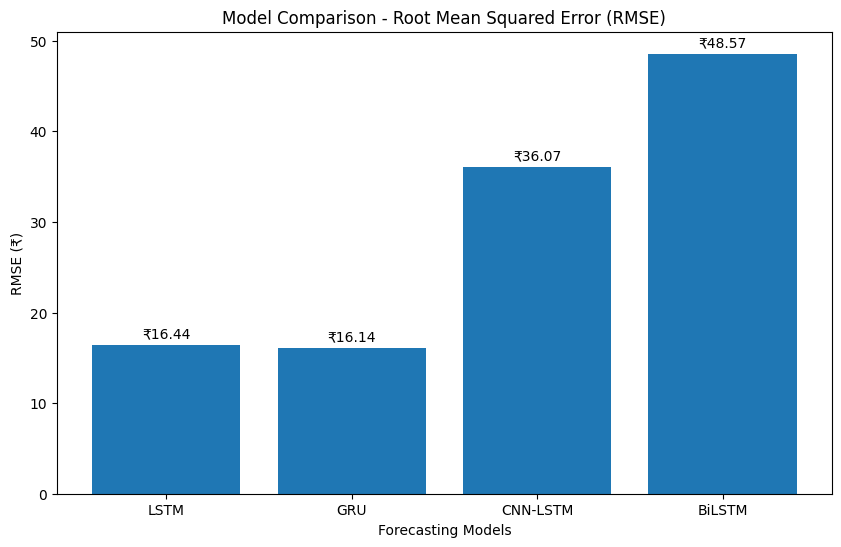

In [15]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_comparison["Model"],
    model_comparison["RMSE (₹)"]
)

plt.title("Model Comparison - Root Mean Squared Error (RMSE)")
plt.xlabel("Forecasting Models")
plt.ylabel("RMSE (₹)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"₹{height:.2f}",
        ha="center"
    )

plt.show()

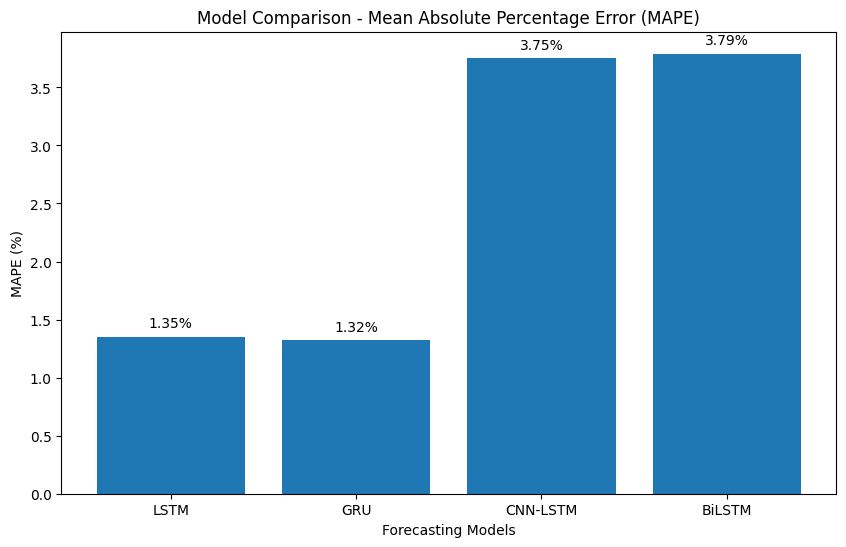

In [16]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_comparison["Model"],
    model_comparison["MAPE (%)"]
)

plt.title("Model Comparison - Mean Absolute Percentage Error (MAPE)")
plt.xlabel("Forecasting Models")
plt.ylabel("MAPE (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.08,
        f"{height:.2f}%",
        ha="center"
    )

plt.show()

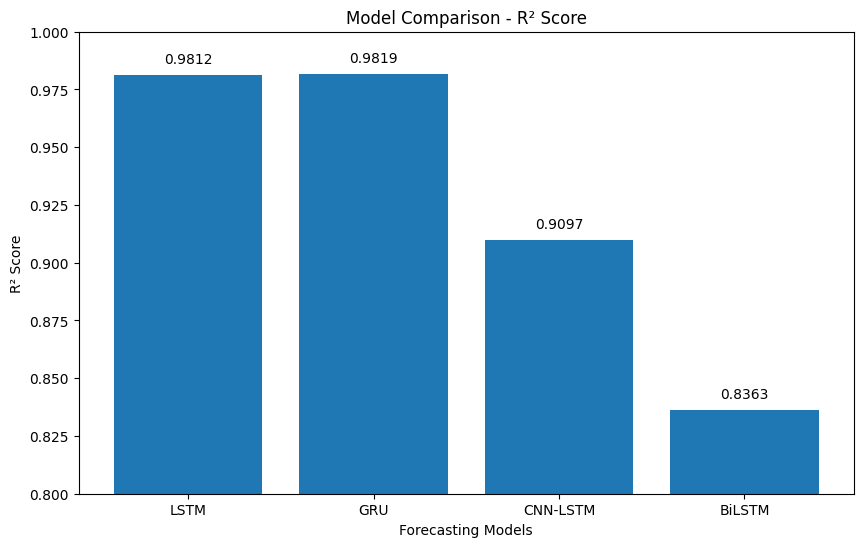

In [17]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    model_comparison["Model"],
    model_comparison["R² Score"]
)

plt.title("Model Comparison - R² Score")
plt.xlabel("Forecasting Models")
plt.ylabel("R² Score")

plt.ylim(0.80, 1.0)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.4f}",
        ha="center"
    )

plt.show()

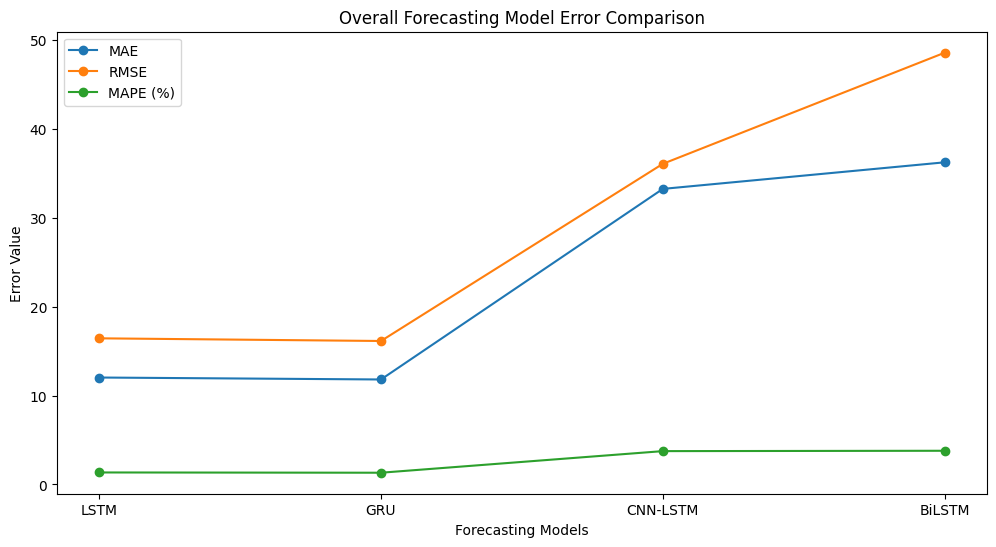

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(model_comparison))

ax.plot(
    model_comparison["Model"],
    model_comparison["MAE (₹)"],
    marker="o",
    label="MAE"
)

ax.plot(
    model_comparison["Model"],
    model_comparison["RMSE (₹)"],
    marker="o",
    label="RMSE"
)

ax.plot(
    model_comparison["Model"],
    model_comparison["MAPE (%)"],
    marker="o",
    label="MAPE (%)"
)

ax.set_title("Overall Forecasting Model Error Comparison")
ax.set_xlabel("Forecasting Models")
ax.set_ylabel("Error Value")

ax.legend()

plt.show()

In [19]:
# Select the best model based on lowest RMSE
best_model = model_comparison.loc[
    model_comparison["RMSE (₹)"].idxmin()
]

print("🏆 BEST FORECASTING MODEL")
print("=" * 40)

print(f"Model: {best_model['Model']}")
print(f"MAE: ₹{best_model['MAE (₹)']:.2f}")
print(f"RMSE: ₹{best_model['RMSE (₹)']:.2f}")
print(f"MAPE: {best_model['MAPE (%)']:.2f}%")
print(f"R² Score: {best_model['R² Score']:.4f}")

🏆 BEST FORECASTING MODEL
Model: GRU
MAE: ₹11.81
RMSE: ₹16.14
MAPE: 1.32%
R² Score: 0.9819


In [20]:
final_ranking = model_comparison.copy()

final_ranking = final_ranking.sort_values(
    by="RMSE (₹)",
    ascending=True
).reset_index(drop=True)

final_ranking.insert(
    0,
    "Rank",
    range(1, len(final_ranking) + 1)
)

final_ranking

,Rank,Model,MAE (₹),RMSE (₹),MAPE (%),R² Score
0,1,GRU,11.81,16.14,1.32,0.9819
1,2,LSTM,12.03,16.44,1.35,0.9812
2,3,CNN-LSTM,33.25,36.07,3.75,0.9097
3,4,BiLSTM,36.24,48.57,3.79,0.8363


# Final Conclusion

In this notebook, four deep learning models were implemented and evaluated for stock price forecasting:

- Long Short-Term Memory (LSTM)
- Gated Recurrent Unit (GRU)
- CNN-LSTM
- Bidirectional LSTM (BiLSTM)

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE), and R² Score.

Among all the models, the GRU model achieved the best overall performance with:

- MAE: ₹11.81
- RMSE: ₹16.14
- MAPE: 1.32%
- R² Score: 0.9819

The GRU model produced the lowest prediction errors and the highest R² Score among the evaluated models. Therefore, GRU was selected as the best-performing forecasting model for the SBIN stock price dataset.

The results demonstrate that deep learning models can effectively capture temporal patterns in historical stock price data. However, stock market forecasting remains challenging because future prices can also be affected by external factors such as market sentiment, economic events, and unexpected news.

For the AI Stock Analytics and Decision Support System, the GRU model will be considered as the primary deep learning model for stock price forecasting.